In [26]:
"""
Visualisation temps réel de l'AG-TSP — ADEME / CesiCDP
Affichage animé génération par génération dans une fenêtre matplotlib.

Lancer avec :  python tsp_visualisation.py
"""

import random
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import csv
import os
from pathlib import Path
from split_dataset import chunk_file_by_rows, collect_solomon_dataset

## Section 1 — Modèle : villes et matrice de distances

La classe `Ville` représente un nœud du graphe avec ses coordonnées `(x, y)`. La distance entre deux villes est calculée par la **distance euclidienne** :

$$d(a, b) = \sqrt{(x_a - x_b)^2 + (y_a - y_b)^2}$$

La fonction `construire_matrice` génère la matrice de distances complète $D \in \mathbb{R}^{n \times n}$ où $D_{ij} = d(v_i, v_j)$. C'est un graphe complet non orienté.

Les fonctions `charger_villes_*` peuplent ce graphe depuis des fichiers CSV (format Solomon ou TSP).

In [27]:

class Ville:
    def __init__(self, nom: str, x: float, y: float):
        self.nom = nom
        self.x   = x
        self.y   = y
    def __repr__(self):
        return self.nom


def duree_trajet(a: Ville, b: Ville) -> float:
    return math.sqrt((a.x - b.x) ** 2 + (a.y - b.y) ** 2)


def construire_matrice(villes: list) -> list:
    n = len(villes)
    return [[duree_trajet(villes[i], villes[j]) for j in range(n)] for i in range(n)]

def charger_villes_csv_tsp(chemin_csv, chunk_size) -> list:
    """Parser pour tsp_dataset.csv dont les coords sont stockées comme [[x,y],[x,y],...]"""
    import ast

    # sys.maxsize trop grand sur Windows — on utilise une valeur fixe compatible C long
    csv.field_size_limit(10_000_000)

    villes = []

    with open(chemin_csv, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            coords_str = row.get('city_coordinates')
            if not coords_str:
                continue
            try:
                coords = ast.literal_eval(coords_str)
                for point in coords:
                    idx = len(villes)
                    villes.append(Ville(f"Ville {idx}", float(point[0]), float(point[1])))
                    if len(villes) >= chunk_size:
                        return villes
            except Exception:
                continue

    return villes


def charger_villes_depuis_split(chunk_size: int = 20, source: str = "solomon") -> list:
    raw_dir = Path("./dataset_raw")

    if source == "solomon":
        groupes = collect_solomon_dataset(raw_dir)
        tous_les_fichiers = []
        for fichiers in groupes.values():
            tous_les_fichiers.extend(fichiers)

        if not tous_les_fichiers:
            raise FileNotFoundError("Aucun fichier Solomon trouvé dans dataset_raw")

        villes = []
        for chemin_csv in tous_les_fichiers:
            with open(chemin_csv, newline='', encoding='utf-8') as f:
                reader = csv.reader(f)
                next(reader)  # skip header
                for row in reader:
                    if len(row) < 3:
                        continue
                    idx = len(villes)
                    villes.append(Ville(f"Ville {idx}", float(row[1]), float(row[2])))
                    if len(villes) >= chunk_size:
                        return villes
        return villes

    elif source == "tsp":
        tsp_src = raw_dir / "chunks" / "tsp_dataset" / "tsp_dataset.csv"

        if not tsp_src.exists():
            raise FileNotFoundError(f"Fichier TSP introuvable : {tsp_src.resolve()}")

        return charger_villes_csv_tsp(tsp_src, chunk_size)

    raise ValueError(f"Source inconnue : '{source}'. Valeurs acceptées : 'solomon', 'tsp'")


def charger_villes_csv(chemin_csv):
    villes = []

    with open(chemin_csv, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)  # skip header

        for row in reader:
            if len(row) < 3: continue
            nom = f"Ville {row[0]}"
            x = float(row[1])
            y = float(row[2])

            villes.append(Ville(nom, x, y))

    return villes

def charger_villes_depuis_dossiers(nb_fichiers):
    base_path = r"dataset_split\split_60_20_20\test\solomon_dataset"

    villes = []
    fichiers_pris = 0

    for dossier in sorted(os.listdir(base_path)):
        dossier_path = os.path.join(base_path, dossier)

        if os.path.isdir(dossier_path):
            for fichier in sorted(os.listdir(dossier_path)):
                if fichier.endswith(".csv"):
                    chemin_csv = os.path.join(dossier_path, fichier)

                    villes += charger_villes_csv(chemin_csv)
                    fichiers_pris += 1

                    if fichiers_pris >= nb_fichiers:
                        return villes

    return villes

## Section 2 — Opérateurs génétiques

C'est le cœur de l'algorithme. Chaque individu est un **chromosome** : une permutation des indices de villes (hors dépôt).

### Fitness

La fonction de fitness mesure la longueur totale d'une tournée en bouclant sur le dépôt (indice 0) :

$$f(\pi) = \sum_{i=0}^{n} D_{\pi_i,\, \pi_{i+1}} \quad \text{avec } \pi_0 = \pi_{n+1} = 0$$

### Sélection par tournoi

`selection_tournoi` tire $k$ individus au hasard et retient le plus fit :

$$\pi^* = \arg\min_{\pi \in S_k} f(\pi)$$

### Croisement OX

`ox_crossover` produit un enfant à partir de deux parents $p_1$, $p_2$ en préservant un segment $[a, b]$ de $p_1$ et en complétant avec l'ordre relatif de $p_2$. Il garantit que le chromosome enfant reste une **permutation valide**.

### Mutation 2-opt

`mutation_2opt` inverse un sous-segment aléatoire $[\pi_i, \ldots, \pi_j]$ du chromosome avec probabilité $p_m$ :

$$\pi' = (\pi_1, \ldots, \pi_{i-1},\ \pi_j, \pi_{j-1}, \ldots, \pi_i,\ \pi_{j+1}, \ldots, \pi_n)$$

In [28]:

def fitness(chromosome: list, matrice: list) -> float:
    """Distance totale de la tournée. Dépôt (indice 0) ajouté implicitement."""
    tournee = [0] + chromosome + [0]
    return sum(matrice[tournee[i]][tournee[i + 1]] for i in range(len(tournee) - 1))


def creer_chromosome(n_villes: int) -> list:
    genes = list(range(1, n_villes))
    random.shuffle(genes)
    return genes


def initialiser_population(taille: int, n_villes: int) -> list:
    return [creer_chromosome(n_villes) for _ in range(taille)]


def selection_tournoi(population: list, matrice: list, k: int = 3) -> list:
    candidats = random.sample(population, k)
    return min(candidats, key=lambda c: fitness(c, matrice))


def ox_crossover(p1: list, p2: list) -> list:
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    enfant = [-1] * n
    enfant[a:b + 1] = p1[a:b + 1]
    segment = set(p1[a:b + 1])
    reste = [g for g in p2 if g not in segment]
    pos = 0
    for i in range(n):
        if enfant[i] == -1:
            enfant[i] = reste[pos]
            pos += 1
    return enfant


def mutation_2opt(chromosome: list, taux: float) -> list:
    chrom = chromosome[:]
    if random.random() < taux:
        i, j = sorted(random.sample(range(len(chrom)), 2))
        chrom[i:j + 1] = reversed(chrom[i:j + 1])
    return chrom


## Section 3 — Initialisation de la fenêtre

Purement graphique (matplotlib). La figure est créée **une seule fois** pour éviter de recréer les objets à chaque génération. Seules les *données* des artistes (coordonnées de la route, séries temporelles) sont mises à jour — technique classique d'animation différentielle.

In [29]:

def _init_figure(villes: list):
    """
    Crée la figure matplotlib avec 3 panneaux.
    Les éléments statiques (points des villes, axes) sont dessinés une fois.
    Retourne (fig, artistes) où artistes est un dict des objets à mettre à jour.
    """
    plt.ion()
    fig = plt.figure(figsize=(14, 6), facecolor="#f8f8f6")
    fig.suptitle(
        "Algorithme Génétique — Optimisation de tournées  |  ADEME / CesiCDP",
        fontsize=12, fontweight="bold", color="#2c2c2a", y=0.99,
    )

    gs = gridspec.GridSpec(
        2, 2, figure=fig,
        left=0.06, right=0.97, top=0.93, bottom=0.13,  # bottom plus grand = place pour le texte
        wspace=0.45, hspace=0.50,
    )
    ax_carte  = fig.add_subplot(gs[:, 0])  # toute la colonne gauche
    ax_conv   = fig.add_subplot(gs[0, 1])  # convergence
    ax_divers = fig.add_subplot(gs[1, 1])  # diversité

    # ── Panneau carte : éléments fixes ───────────────────────
    xs = np.array([v.x for v in villes])
    ys = np.array([v.y for v in villes])
    marge = 1

    ax_carte.set_facecolor("#eef3ee")
    ax_carte.set_xlabel("km (est-ouest)", fontsize=9, color="#5f5e5a")
    ax_carte.set_ylabel("km (nord-sud)",  fontsize=9, color="#5f5e5a")
    ax_carte.tick_params(labelsize=8, colors="#5f5e5a")
    ax_carte.set_xlim(xs.min() - marge, xs.max() + marge)
    ax_carte.set_ylim(ys.min() - marge, ys.max() + marge)

    # Points des villes (dessinés une seule fois, ne bougent pas)
    ax_carte.scatter(xs[1:], ys[1:], s=60,  color="#534AB7",
                     zorder=4, edgecolors="white", linewidths=0.8)
    ax_carte.scatter(xs[0],  ys[0],  s=180, color="#BA7517",
                     zorder=5, marker="*", edgecolors="white", linewidths=0.8)

    # Artiste de la route : seules ses données changent à chaque génération
    (ligne_route,) = ax_carte.plot([], [], "-", color="#1D9E75",
                                   linewidth=2, alpha=0.8, zorder=3)

    txt_info = fig.text(
        0.02, 0.01, "",          # x=0.02 (bord gauche), y=0.01 (tout en bas)
        fontsize=9, color="#2c2c2a",
        verticalalignment="bottom", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                alpha=0.85, edgecolor="#d3d1c7"),
    )
    titre_carte = ax_carte.set_title(
        "Génération 0", fontsize=11, color="#2c2c2a", pad=5
    )
    ax_carte.legend(
        handles=[
            Line2D([0],[0], marker="*", color="w",
                   markerfacecolor="#BA7517", markersize=12, label="Dépôt"),
            Line2D([0],[0], marker="o", color="w",
                   markerfacecolor="#534AB7", markersize=7,  label="Livraison"),
            Line2D([0],[0], color="#1D9E75", lw=2, label="Meilleure tournée"),
        ],
        fontsize=8,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),      # x=1.01 = juste à droite du panneau
        borderaxespad=0,
        framealpha=0.85,
        edgecolor="#d3d1c7",
        )

    # ── Panneau convergence : artistes réutilisables ──────────
    ax_conv.set_facecolor("#f8f8f6")
    ax_conv.set_title("Convergence", fontsize=10, color="#2c2c2a", pad=4)
    ax_conv.set_xlabel("Génération", fontsize=8.5, color="#5f5e5a")
    ax_conv.set_ylabel("Distance (km)", fontsize=8.5, color="#5f5e5a")
    ax_conv.tick_params(labelsize=8, colors="#5f5e5a")

    (line_best,)  = ax_conv.plot([], [], color="#0F6E56", lw=2,   label="Meilleure")
    (line_mean,)  = ax_conv.plot([], [], color="#185FA5", lw=1.2, label="Moyenne", alpha=0.75)
    (line_worst,) = ax_conv.plot([], [], color="#993C1D", lw=0.8, label="Pire",
                                  linestyle="--", alpha=0.5)
    fill_ref = [ax_conv.fill_between([], [], [], alpha=0.08, color="#185FA5")]
    ax_conv.legend(fontsize=8, loc="upper right",
                   framealpha=0.85, edgecolor="#d3d1c7")

    # ── Panneau diversité : reconstruit à chaque rafraîchissement
    ax_divers.set_facecolor("#f8f8f6")
    ax_divers.set_title("Diversité population", fontsize=10, color="#2c2c2a", pad=4)
    ax_divers.set_ylabel("Distance (km)", fontsize=8.5, color="#5f5e5a")
    ax_divers.tick_params(labelsize=8, colors="#5f5e5a")
    ax_divers.set_xticks([])

    artistes = dict(
        ax_carte   = ax_carte,
        ax_conv    = ax_conv,
        ax_divers  = ax_divers,
        ligne_route= ligne_route,
        txt_info   = txt_info,
        titre_carte= titre_carte,
        line_best  = line_best,
        line_mean  = line_mean,
        line_worst = line_worst,
        fill_ref   = fill_ref,   # liste mutable pour pouvoir remplacer le patch
    )
    return fig, artistes


## Section 4 — Mise à jour de l'affichage

À chaque rafraîchissement, trois panneaux sont mis à jour :

- **Carte** — tournée courante
- **Courbe de convergence** — meilleur / moyen / pire
- **Boxplot de diversité** — dispersion des fitness

La diversité de population est estimée par l'écart-type des valeurs de fitness :

$$\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\bigl(f(\pi_i) - \bar{f}\bigr)^2}$$


In [30]:

def _maj_affichage(
    fig, artistes, villes,
    generation: int,
    meilleur: list,
    meilleure_dur: float,
    initiale_dur: float,
    hist_best: list,
    hist_mean: list,
    hist_worst: list,
    population: list,
    matrice: list,
):
    ax_conv   = artistes["ax_conv"]
    ax_divers = artistes["ax_divers"]

    # ── Carte ─────────────────────────────────────────────────
    tournee = [0] + meilleur + [0]
    artistes["ligne_route"].set_data(
        [villes[i].x for i in tournee],
        [villes[i].y for i in tournee],
    )
    gain = (initiale_dur - meilleure_dur) / initiale_dur * 100
    artistes["txt_info"].set_text(
        f"Distance : {meilleure_dur:.1f} km\nGain     : -{gain:.1f}%"
    )
    artistes["titre_carte"].set_text(
        f"Meilleure tournée — génération {generation}"
    )

    # ── Convergence ───────────────────────────────────────────
    gens = np.arange(len(hist_best))
    artistes["line_best"].set_data(gens, hist_best)
    artistes["line_mean"].set_data(gens, hist_mean)
    artistes["line_worst"].set_data(gens, hist_worst)

    artistes["fill_ref"][0].remove()
    artistes["fill_ref"][0] = ax_conv.fill_between(
        gens, hist_worst, hist_best, alpha=0.08, color="#185FA5"
    )
    ax_conv.set_xlim(0, max(len(hist_best) + 1, 10))
    ax_conv.set_ylim(min(hist_best) * 0.97, max(hist_worst) * 1.03)

    # ── Diversité (boxplot + strip) ───────────────────────────
    ax_divers.cla()
    ax_divers.set_facecolor("#f8f8f6")
    ax_divers.set_title("Diversité population", fontsize=10, color="#2c2c2a", pad=4)
    ax_divers.set_ylabel("Distance (min)", fontsize=8.5, color="#5f5e5a")
    ax_divers.tick_params(labelsize=8, colors="#5f5e5a")
    ax_divers.set_xticks([])

    durees = np.array([fitness(c, matrice) for c in population])
    ax_divers.boxplot(
        durees, vert=True, patch_artist=True, widths=0.45,
        boxprops    =dict(facecolor="#B5D4F4", color="#185FA5", linewidth=1.2),
        medianprops =dict(color="#0F6E56",     linewidth=2),
        whiskerprops=dict(color="#185FA5",     linewidth=1),
        capprops    =dict(color="#185FA5",     linewidth=1.2),
        flierprops  =dict(marker="o", color="#993C1D", markersize=3, alpha=0.45),
    )
    jitter = np.random.uniform(-0.18, 0.18, len(durees))
    ax_divers.scatter(1 + jitter, durees, alpha=0.2, s=8, color="#534AB7", zorder=2)
    ax_divers.text(
        0.97, 0.97,
        f"min  {durees.min():.0f} km\nmoy  {durees.mean():.0f} km\n"
        f"max  {durees.max():.0f} km\nσ     {durees.std():.0f}",
        transform=ax_divers.transAxes, fontsize=8,
        color="#2c2c2a", va="top", ha="right", family="monospace",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  alpha=0.85, edgecolor="#d3d1c7"),
    )

    fig.canvas.draw()
    fig.canvas.flush_events()
    plt.pause(0.05)


## Section 5 — Boucle principale

C'est la boucle de l'**algorithme génétique** à proprement parler. À chaque génération $t$ :

1. Tri de la population par fitness croissante
2. Conservation des $n_e = \lfloor \alpha \cdot N \rfloor$ meilleurs **(élitisme)**, avec $\alpha$ = `taux_elitisme`
3. Génération de $N - n_e$ enfants par sélection + croisement + mutation
4. Mise à jour du meilleur global

### Critère d'arrêt anticipé

Si $f_{\text{best}}$ ne s'améliore pas pendant $p$ générations consécutives (`patience`), l'algorithme s'arrête.

### Gain final

$$\text{Gain} = \frac{f_0 - f^*}{f_0} \times 100\%$$

où $f_0$ est la fitness de la solution initiale et $f^*$ la meilleure solution trouvée.


In [32]:

def lancer_visualisation(
    villes: list,
    taille_pop: int        = 80,
    n_generations: int     = 300,
    taux_croisement: float = 0.85,
    taux_mutation: float   = 0.12,
    taux_elitisme: float   = 0.10,
    patience: int          = 80,
) -> tuple:
    """
    Lance l'AG et affiche son évolution génération par génération.

    Paramètres
    ----------
    villes          : liste de Ville (index 0 = dépôt)
    taille_pop      : nombre d'individus dans la population
    n_generations   : nombre maximum de générations
    taux_croisement : probabilité de croisement OX
    taux_mutation   : probabilité de mutation 2-opt
    taux_elitisme   : fraction des meilleurs conservés sans modification
    patience        : arrêt si aucune amélioration pendant N générations
    intervalle      : rafraîchir l'affichage toutes les N générations
                      1 = chaque génération (fluide), 5+ = plus rapide

    Retourne
    --------
    (meilleur_chromosome, meilleure_Distance, historique_best)
    """
    if len(villes) < 3:
        print("Erreur : Il faut au moins 3 villes pour lancer l'algorithme génétique.")
        return None, 0, []

    n_villes  = len(villes)
    matrice   = construire_matrice(villes)
    n_elite   = max(1, int(taille_pop * taux_elitisme))

    population    = initialiser_population(taille_pop, n_villes)
    meilleur      = min(population, key=lambda c: fitness(c, matrice))
    meilleure_dur = fitness(meilleur, matrice)
    initiale_dur  = meilleure_dur

    hist_best  = [meilleure_dur]
    hist_mean  = [float(np.mean([fitness(c, matrice) for c in population]))]
    hist_worst = [float(np.max( [fitness(c, matrice) for c in population]))]
    sans_amelioration = 0

    # Fenêtre créée une seule fois
    fig, artistes = _init_figure(villes)


    debut = time.time()

    for gen in range(1, n_generations + 1):

        # ── Une génération ────────────────────────────────────
        population.sort(key=lambda c: fitness(c, matrice))
        nouvelle_pop = population[:n_elite]

        while len(nouvelle_pop) < taille_pop:
            p1     = selection_tournoi(population, matrice)
            p2     = selection_tournoi(population, matrice)
            enfant = ox_crossover(p1, p2) if random.random() < taux_croisement else p1[:]
            enfant = mutation_2opt(enfant, taux_mutation)
            nouvelle_pop.append(enfant)

        population   = nouvelle_pop
        dur_candidat = fitness(population[0], matrice)

        if dur_candidat < meilleure_dur:
            meilleure_dur     = dur_candidat
            meilleur          = population[0][:]
            sans_amelioration = 0
        else:
            sans_amelioration += 1

        durees_pop = [fitness(c, matrice) for c in population]
        hist_best.append(meilleure_dur)
        hist_mean.append(float(np.mean(durees_pop)))
        hist_worst.append(float(np.max(durees_pop)))


        if sans_amelioration >= patience:
            print(f"  Arrêt anticipé — génération {gen} "
                  f"(stagnation sur {patience} gén.)")
            break

    # Rendu final
    _maj_affichage(fig, artistes, villes, gen,
                   meilleur, meilleure_dur, initiale_dur,
                   hist_best, hist_mean, hist_worst,
                   population, matrice)

    duree_calcul = time.time() - debut
    gain_final   = (initiale_dur - meilleure_dur) / initiale_dur * 100
    print(f"\n  Terminé en {duree_calcul:.2f}s  |  "
        f"{initiale_dur:.0f} km → {meilleure_dur:.0f} km  |  "
        f"Gain : -{gain_final:.1f}%")

    plt.ioff()
    plt.show()   # bloque jusqu'à fermeture de la fenêtre
    return meilleur, meilleure_dur, hist_best


Villes chargées : 10
  Arrêt anticipé — génération 359 (stagnation sur 350 gén.)


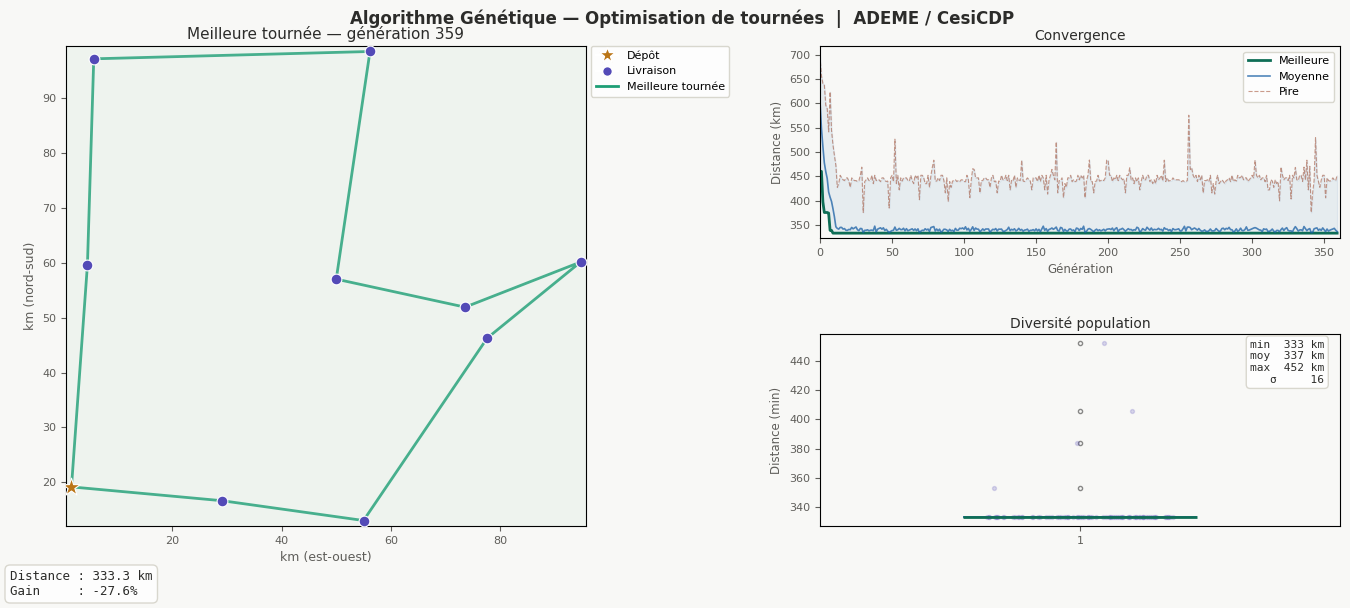


  Terminé en 0.76s  |  460 km → 333 km  |  Gain : -27.6%


In [33]:
villes = charger_villes_depuis_split(chunk_size=10, source="tsp")
print(f"Villes chargées : {len(villes)}")
lancer_visualisation(
    villes,
    taille_pop      = 80,
    n_generations   = 10000,
    taux_croisement = 0.85,
    taux_mutation   = 0.12,
    taux_elitisme   = 0.10,
    patience        = 350,
);

Villes chargées : 100
  Arrêt anticipé — génération 2689 (stagnation sur 350 gén.)


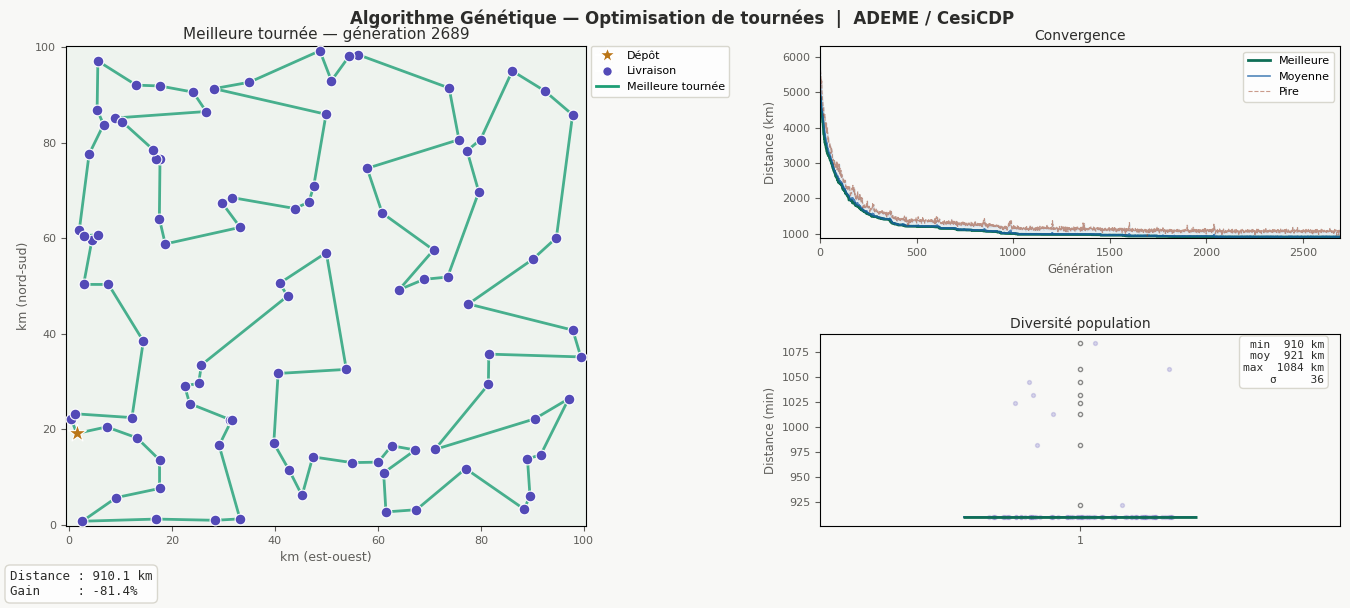


  Terminé en 13.12s  |  4885 km → 910 km  |  Gain : -81.4%


In [10]:
villes = charger_villes_depuis_split(chunk_size=100, source="tsp")
print(f"Villes chargées : {len(villes)}")
lancer_visualisation(
    villes,
    taille_pop      = 80,
    n_generations   = 10000,
    taux_croisement = 0.85,
    taux_mutation   = 0.12,
    taux_elitisme   = 0.10,
    patience        = 350,
);

Villes chargées : 200
  Arrêt anticipé — génération 5539 (stagnation sur 350 gén.)


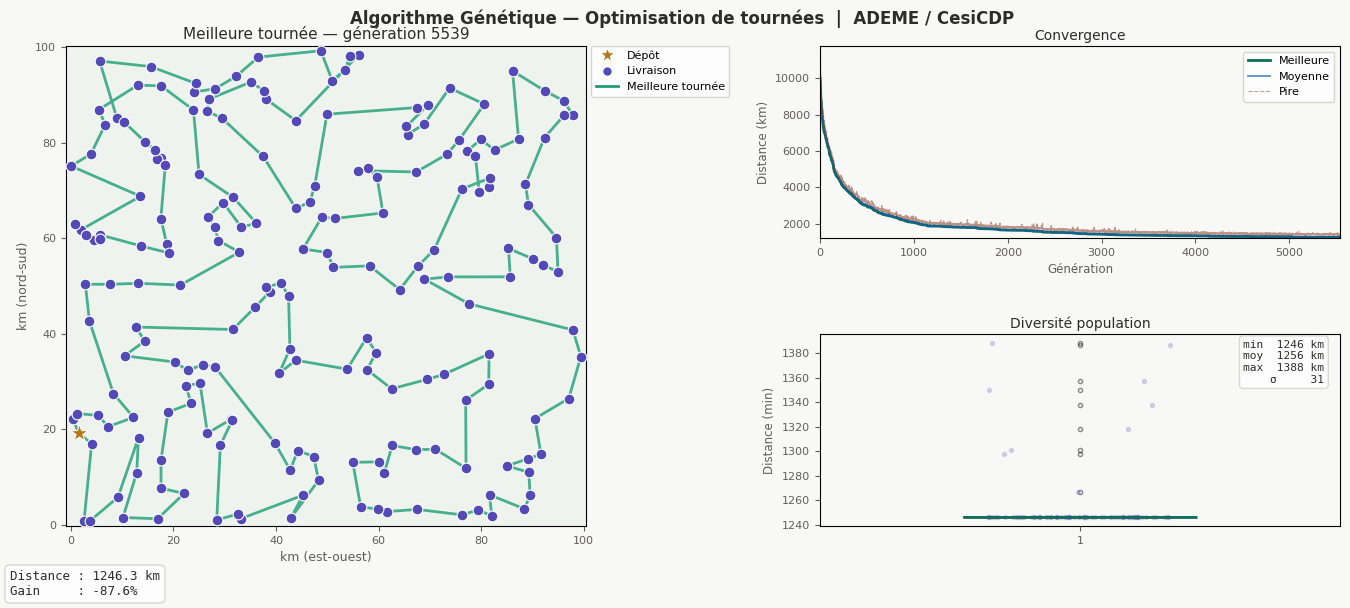


  Terminé en 48.94s  |  10030 km → 1246 km  |  Gain : -87.6%


In [11]:
villes = charger_villes_depuis_split(chunk_size=200, source="tsp")
print(f"Villes chargées : {len(villes)}")
lancer_visualisation(
    villes,
    taille_pop      = 80,
    n_generations   = 10000,
    taux_croisement = 0.85,
    taux_mutation   = 0.12,
    taux_elitisme   = 0.10,
    patience        = 350,
);

Villes chargées : 500
  Arrêt anticipé — génération 16596 (stagnation sur 350 gén.)


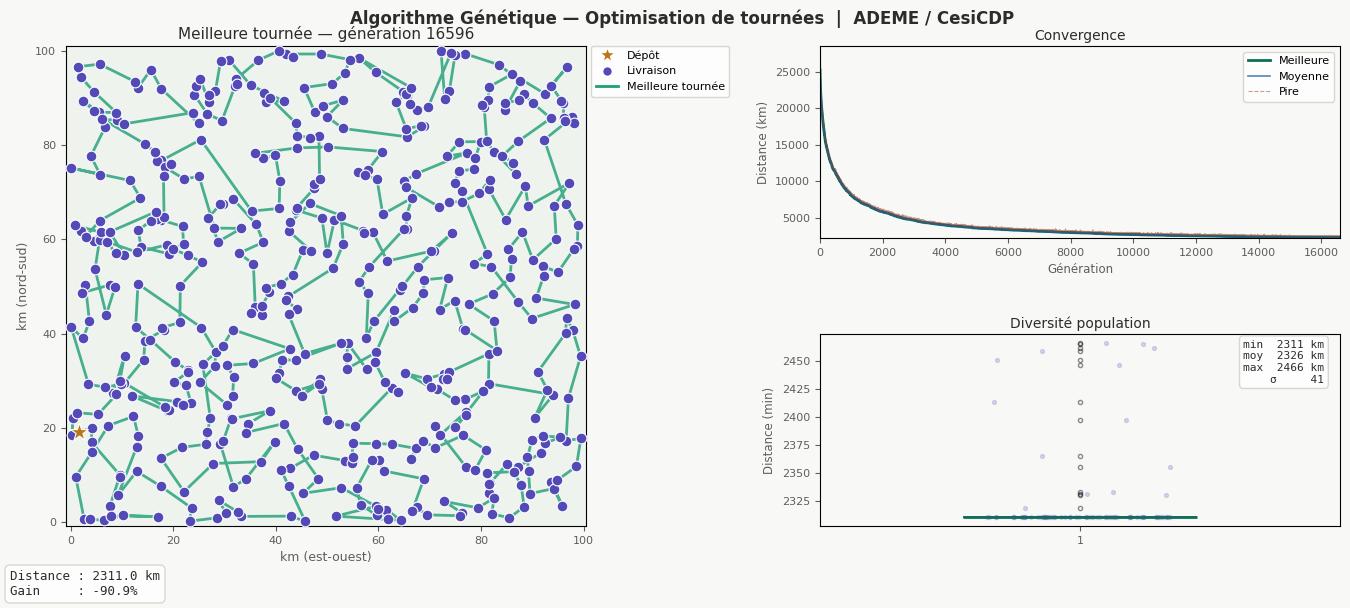


  Terminé en 437.04s  |  25320 km → 2311 km  |  Gain : -90.9%


In [13]:
villes = charger_villes_depuis_split(chunk_size=500, source="tsp")
print(f"Villes chargées : {len(villes)}")
lancer_visualisation(
    villes,
    taille_pop      = 80,
    n_generations   = 20000,
    taux_croisement = 0.85,
    taux_mutation   = 0.12,
    taux_elitisme   = 0.10,
    patience        = 350,
);

Villes chargées : 1000
  Arrêt anticipé — génération 74813 (stagnation sur 500 gén.)


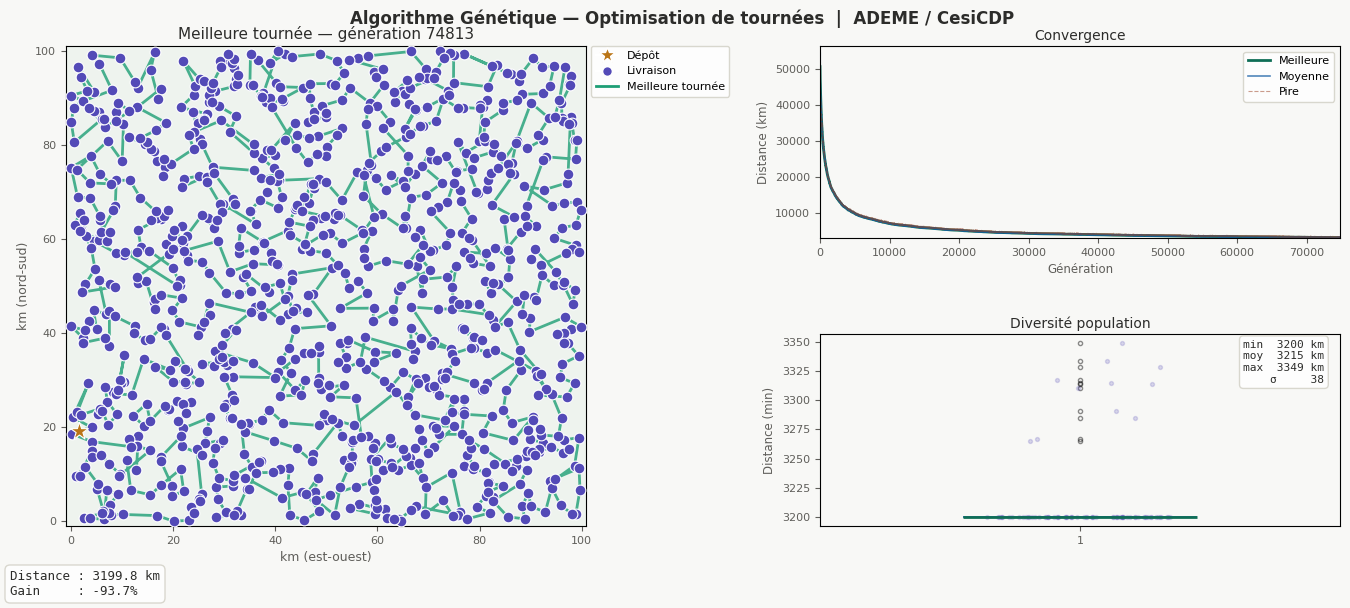


  Terminé en 5109.98s  |  50838 km → 3200 km  |  Gain : -93.7%


In [19]:
villes = charger_villes_depuis_split(chunk_size=1000, source="tsp")
print(f"Villes chargées : {len(villes)}")
lancer_visualisation(
    villes,
    taille_pop      = 80,
    n_generations   = 1000000,
    taux_croisement = 0.85,
    taux_mutation   = 0.12,
    taux_elitisme   = 0.10,
    patience        = 500,
);